# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [161]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [162]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [163]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

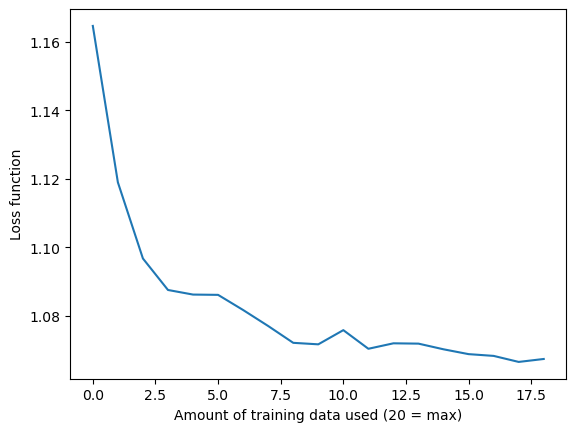

In [164]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [165]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

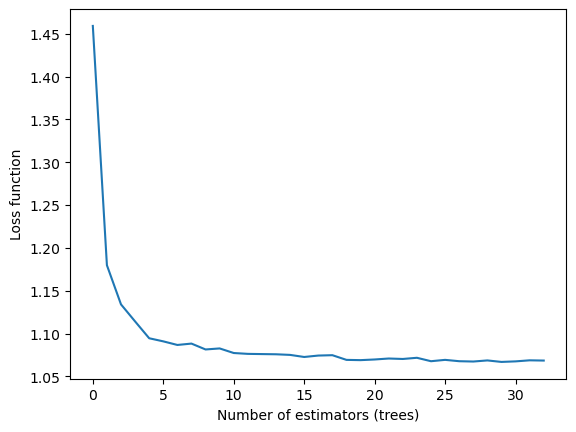

In [166]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

**ANSWER**

I would cut the first chart. I think the elbow curve of the number of estimators is more appropriate, as the it is more conventional.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [167]:
df = pd.read_csv('T_ONTIME_REPORTING.csv')

In [168]:
df.head()

,YEAR,MONTH,FL_DATE,OP_UNIQUE_CARRIER,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST_AIRPORT_ID,...,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,2026,1,1/1/2026 12:00:00 AM,AA,10140,1014006,30140,"Albuquerque, NM",NM,11298,...,0.0,122.0,96.0,74.0,569.0,NaN,NaN,NaN,NaN,NaN
1,2026,1,1/1/2026 12:00:00 AM,AA,10140,1014006,30140,"Albuquerque, NM",NM,11298,...,0.0,122.0,97.0,73.0,569.0,NaN,NaN,NaN,NaN,NaN
2,2026,1,1/1/2026 12:00:00 AM,AA,10140,1014006,30140,"Albuquerque, NM",NM,11298,...,0.0,120.0,105.0,81.0,569.0,2021.0,0.0,0.0,0.0,0.0
3,2026,1,1/1/2026 12:00:00 AM,AA,10140,1014006,30140,"Albuquerque, NM",NM,11298,...,0.0,120.0,89.0,75.0,569.0,NaN,NaN,NaN,NaN,NaN
4,2026,1,1/1/2026 12:00:00 AM,AA,10140,1014006,30140,"Albuquerque, NM",NM,11298,...,0.0,124.0,96.0,76.0,569.0,0.0,0.0,0.0,0.0,86.0


In [169]:
cat_cols = ['OP_UNIQUE_CARRIER','ORIGIN_AIRPORT_ID','DEST_AIRPORT_ID']
cols_drop = ['ACTUAL_ELAPSED_TIME','CRS_ELAPSED_TIME','AIR_TIME','CRS_ARR_TIME','ARR_TIME','ARR_DELAY','YEAR','MONTH']
num_cols = ['DEP_DELAY','DEP_TIME','TAXI_OUT','WHEELS_OFF','DIVERTED','DISTANCE','ARR_DEL15']
del_cols = ['DEP_DELAY','DEP_TIME','CARRIER_DELAY','WEATHER_DELAY','NAS_DELAY','SECURITY_DELAY','LATE_AIRCRAFT_DELAY','DEP_DEL15','TAXI_OUT','WHEELS_OFF','CRS_DEP_TIME']
y = ['ARR_DEL15']

In [170]:
# Preparing the data for regression

# Creating dummy variable columns for every categorical column
df_ready = pd.get_dummies(df, columns=cat_cols, dtype=int)
df_ready[num_cols] = df[num_cols]
df_ready = df_ready.select_dtypes(include='number')
df_ready = df_ready.drop(columns=cols_drop)
df_ready = df_ready.drop(columns=del_cols)
df_ready = df_ready.fillna(0)

In [171]:
X = df_ready.drop(columns='ARR_DEL15')
Y = df_ready[y]
print(f"{sum(Y.isnull().sum())}")
print(f"{sum(X.isnull().sum())}")

0
0


In [172]:
X

,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,CANCELLED,DIVERTED,DISTANCE,OP_UNIQUE_CARRIER_AA,OP_UNIQUE_CARRIER_AS,OP_UNIQUE_CARRIER_B6,...,DEST_AIRPORT_ID_15412,DEST_AIRPORT_ID_15569,DEST_AIRPORT_ID_15624,DEST_AIRPORT_ID_15628,DEST_AIRPORT_ID_15841,DEST_AIRPORT_ID_15919,DEST_AIRPORT_ID_15991,DEST_AIRPORT_ID_16218,DEST_AIRPORT_ID_16422,DEST_AIRPORT_ID_16869
0,1014006,30140,1129806,30194,0.0,0.0,569.0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1014006,30140,1129806,30194,0.0,0.0,569.0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1014006,30140,1129806,30194,0.0,0.0,569.0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1014006,30140,1129806,30194,0.0,0.0,569.0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1014006,30140,1129806,30194,0.0,0.0,569.0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543998,1537003,34653,1393008,30977,0.0,0.0,585.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
543999,1538005,35380,1393008,30977,0.0,0.0,224.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
544000,1562405,31504,1127805,30852,0.0,0.0,789.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
544001,1591905,31834,1295304,31703,0.0,0.0,1147.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [173]:
# Train Test Split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=.33, random_state=42
)

In [174]:
rfr = RandomForestClassifier()
rfr.fit(x_train, y_train)

C:\Users\Owner\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [175]:
print("RMSE when predicting training data:")
print(root_mean_squared_error(rfr.predict(x_train), y_train))
print("RMSE when predicting testing data:")
print(root_mean_squared_error(rfr.predict(x_test), y_test))
test_target_shuffle = test_target.copy()
np.random.shuffle(test_target_shuffle)
print("RMSE with random predictions:")
print(root_mean_squared_error(test_target_shuffle, test_target))

RMSE when predicting training data:
0.4412586585515202
RMSE when predicting testing data:
0.4482201326519995
RMSE with random predictions:
5.275250695584346


In [176]:
train_preds = rfr.predict(x_train)
test_preds = rfr.predict(x_test)

from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Train accuracy: 0.8052907962533129
Test accuracy: 0.799098712685424


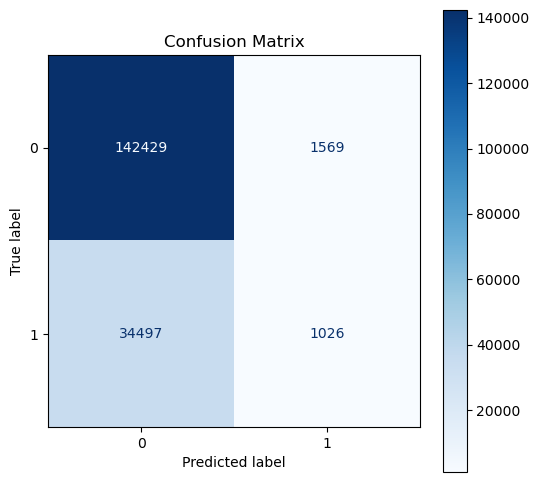

In [177]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_preds,
    cmap="Blues",
    display_labels=["0", "1"],
    normalize=None,
    ax=ax
)
ax.set_title("Confusion Matrix")
plt.show()

**CROSS VALIDATION AND HYPERPARAMETER TUNING**

In [211]:
param_grid = {
    "max_depth": [5, 10, 20, None],
    "min_samples_leaf": [1, 2, 5],
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=1,
        class_weight="balanced"
    ),
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=1,
    verbose=1
)

grid.fit(x_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


C:\Users\Owner\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\Owner\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\Owner\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\Owner\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed whe

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...]}"
,scoring,'f1'
,n_jobs,1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


C:\Users\Owner\AppData\Local\Temp\ipykernel_7280\1073271096.py:3: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  plot_data = results.pivot(


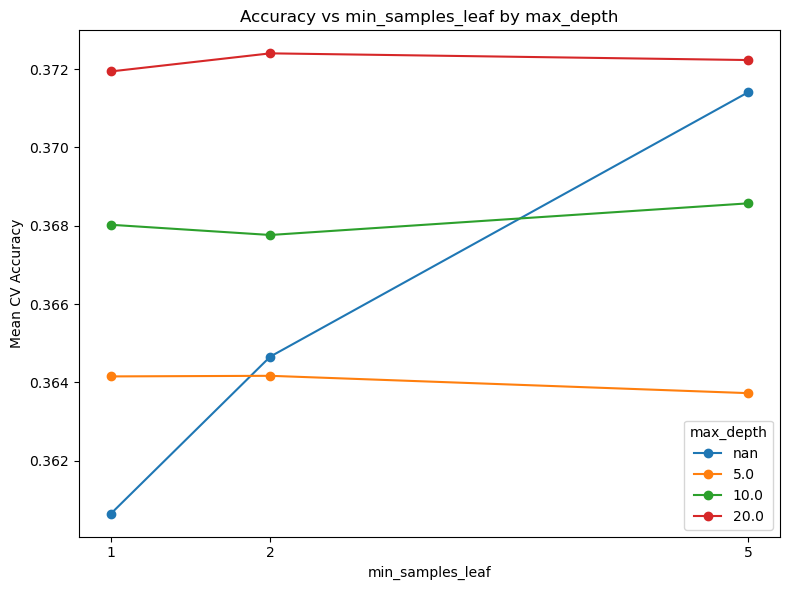

In [212]:
results = pd.DataFrame(grid.cv_results_)

plot_data = results.pivot(
    index="param_min_samples_leaf",
    columns="param_max_depth",
    values="mean_test_score"
)

plot_data.plot(marker="o", figsize=(8, 6))

plt.xlabel("min_samples_leaf")
plt.ylabel("Mean CV Accuracy")
plt.title("Accuracy vs min_samples_leaf by max_depth")
plt.xticks([1, 2, 5])
plt.legend(title="max_depth")
plt.tight_layout()
plt.show()

In [213]:
best_idx = results["mean_test_score"].idxmax()
print("Best combination:")
print(results.loc[best_idx, ["params", "mean_test_score", "std_test_score"]])

Best combination:
params             {'max_depth': 20, 'min_samples_leaf': 2}
mean_test_score                                    0.372402
std_test_score                                     0.001491
Name: 7, dtype: object


In [207]:
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

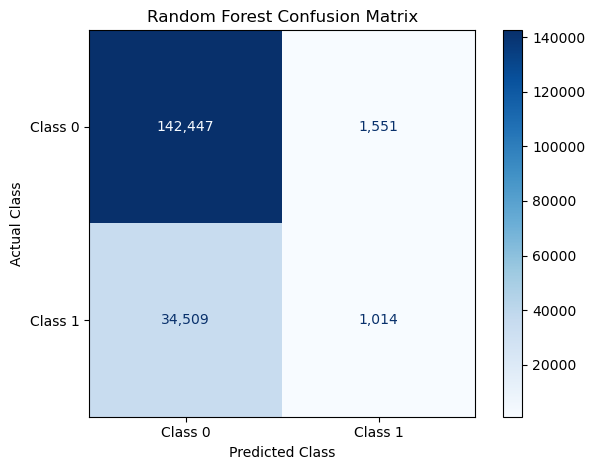

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1"],
    cmap="Blues",
    values_format=","
)

plt.title("\Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

**CONCLUSION**

- during hyperparameter tuning, the scoring method used was the f1 score, because there is a class imbalance and both classes were important. Using this, the model clearly is biased towards non delayed flights and has a problem with false positives.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.